# Grammar scoring: improvement experiments

Run the original notebook first to generate private intermediate features. This public notebook contains aggregate results generated from completed experiment artifacts; notebook execution counts are unset. Enable `RUN_TRAINING` to rerun the model experiments.

In [ ]:
from pathlib import Path
import subprocess, sys, json
ROOT = Path.cwd()
assert (ROOT / 'experiments').exists(), 'Open this notebook from the repository root.'
# Set True after running the original notebook to regenerate the improvement experiments.
RUN_TRAINING = False
if RUN_TRAINING:
    for script in ['extract_acoustics.py', 'improve_models.py', 'extract_speech.py',
                   'evaluate_speech.py', 'select_candidate.py', 'validate_candidate.py',
                   'build_improvement_report.py']:
        subprocess.run([sys.executable, str(ROOT / 'experiments' / script)], check=True)


# Improved spoken grammar scorer

The original submission scored **0.4912** on Kaggle's public leaderboard. The competition describes a custom metric involving RMSE and Pearson correlation; that leaderboard value is not directly interchangeable with local RMSE. The new submission, `Ronit_Mia_v2.csv`, scored **0.4337**, improving on **0.4912** (11.7% lower). The signed-in leaderboard showed rank **131** and a leading score of **0.3064** on 7 October 2026. These ranks are time-dependent; first place has not been achieved.

## Method

We retained the original audio-hash-grouped five folds and training labels. We compared larger tree ensembles and support-vector regressors with and without text embeddings; added 522 spectral/temporal audio functionals; and extracted frozen Wav2Vec2 features from all recordings using layers 6, 9 and 12. Ten-second chunks cover the recording, with frame-weighted mean and standard-deviation pooling. No external dataset or test labels were used. Audio stayed local.

Feature imputation, scaling and any PCA are fitted inside each training fold. The pretrained speech encoder is frozen. Joint SVR candidates balance speech and handcrafted feature blocks; joint tree candidates use 32 speech principal components learned within each training fold. Candidate selection uses development OOF predictions, not leaderboard feedback.

## Selected model and measured results

- Handcrafted-feature component: `extended_cat_d5`.
- Speech-feature component: `speech6_svr10`.
- Speech component weight: 75%; handcrafted component weight: 25%.
- Original development OOF: RMSE **0.6609**, Pearson **0.8458**.
- New development OOF: RMSE **0.5552**, Pearson **0.8963**.
- Secondary split (seed 2026): candidate RMSE **0.5546**, Pearson **0.8964**.
- Baseline architecture on that same secondary split, without its original nested calibration: RMSE **0.6783**, Pearson **0.8393**.
- Full-fit training RMSE **0.0778**, Pearson **0.9985**.

Test predictions average the full-training fit and the original five-fold bagged model. The CSV contains 216 finite predictions between 0 and 5, in official test-file order.

## Validation limits

These are development estimates. Selecting models and blends on reused folds introduces selection optimism. The second split checks stability but is not an untouched holdout. Speaker identities are unavailable; distinct recordings from the same speaker may occur across folds. No local result guarantees a leaderboard rank, and the public leaderboard covers only approximately 60% of test examples.

## Reproduction

First run `grammar_scoring_engine.ipynb` to generate the baseline transcripts, features and fold assignments. Then run `extract_acoustics.py`, `improve_models.py`, `extract_speech.py`, `evaluate_speech.py`, `select_candidate.py`, and `validate_candidate.py` from `experiments/`, followed by this report generator. The improvement notebook provides the same sequence. Fresh environments are recommended; the actual run used an isolated installation because the existing local PyTorch installation had an import inconsistency.

Pretrained model: [facebook/wav2vec2-base-960h](https://huggingface.co/facebook/wav2vec2-base-960h), Apache-2.0, revision `22aad52d435eb6dbaf354bdad9b0da84ce7d6156`.


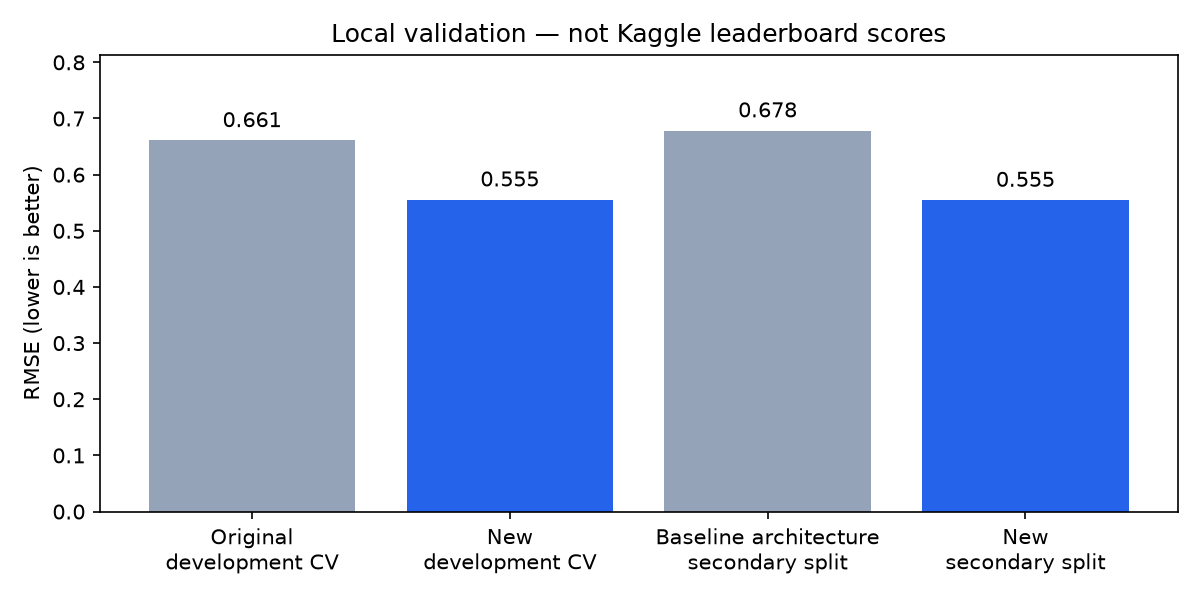

In [ ]:
from IPython.display import display, Markdown, Image
display(Markdown((ROOT / 'experiments/results/improvement_report.md').read_text()))
display(Image(filename=str(ROOT / 'experiments/results/improvement_validation.png')))
